# Module 5: Dynamic Traffic Control with RL Triggered by Anomaly Detection

**Goal:**  
- Demonstrate an RL agent controlling traffic signals/intersection flow using state input from historical traffic and real-time anomaly flags.
- Reward = negative waiting time (and optionally anomaly handling/fairness/emission proxies).

---

**Input:**  
- `vae_anomaly_results.csv` (from previous module; per time step traffic, anomaly flag, etc.)

**Output:**  
- Sequence of actions taken by the RL controller (e.g., extend green, switch phase) and performance improvement stats.

## 1. Load State Data for RL

We use `vae_anomaly_results.csv` as the environment's traffic state, including anomaly triggers.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("vae_anomaly_results.csv")
print(df.head())

# State can include: current vehicle count, anomaly score, anomaly flag
states = df[["true_vehicle_count", "vae_anomaly_score", "is_anomaly"]].values
print(f"Total steps: {states.shape[0]}")

   frame_idx  true_vehicle_count  vae_anomaly_score  is_anomaly
0       7987                 7.0           0.012232           0
1       7988                 6.0           0.012028           0
2       7989                 2.0           0.011881           0
3       7990                 4.0           0.009552           0
4       7991                 6.0           0.006349           0
Total steps: 1993


## 2. Define a Traffic Light Environment

For illustration:  
- **State**: [vehicle count, anomaly score, anomaly flag]
- **Actions**: [0] = "standard timing", [1] = "emergency timing" (e.g., extend green or trigger priority response)
- **Reward**: Negative of vehicle count (proxy for queue length; real deployment can include fairness or emissions)
- If anomaly is present and action avoids congestion, *bonus reward*.

In [ ]:
class SimpleIntersectionEnv:
    def __init__(self, states):
        self.states = states
        self.n = len(states)
        self.reset()

    def reset(self):
        self.t = 0
        return self.states[self.t]

    def step(self, action):
        # Next state is deterministic (just indexed), action impacts reward
        self.t += 1
        done = (self.t >= self.n-1)
        state = self.states[self.t]
        veh, anomaly_score, anomaly = state

        # Reward: encourage low congestion (low cars in queue); bonus for correctly handling anomaly
        reward = -veh
        if anomaly == 1:
            if action == 1:
                reward += 10  # 'correct' anomaly handling (e.g., reroute, extend green)
            else:
                reward -= 10  # 'missed' opportunity
        # Small penalty for excessive switching (optional—add if multiple actions)
        return state, reward, done

## 3. RL Agent: Q-Learning

Tabular Q-Learning for simplicity, with discretized states (for demo).  
- **States**: bucketized (`vehicle_count`, `is_anomaly`)  
- **Actions**: 0/1 as above  
- **Q-Table**: Q[state, action]

In [ ]:
# Discretize states for demo Q-table
def state_to_key(state):
    # bucketize vehicle count (0-5: low, 6-12: med, 13+: high), anomaly 0/1
    veh, anomaly_score, anomaly = state
    veh_bucket = int(min(veh//6, 2))  # 0, 1, or 2
    return (veh_bucket, int(anomaly))

ACTIONS = [0, 1]  # 0: Standard, 1: Extended green/"anomaly mode"
Q = {}

def choose_action(state, epsilon=0.1):
    key = state_to_key(state)
    if np.random.rand() < epsilon:
        return np.random.choice(ACTIONS)
    qvals = [Q.get((key,a), 0.0) for a in ACTIONS]
    return ACTIONS[int(np.argmax(qvals))]

def update_q(state, action, reward, next_state, lr=0.1, gamma=0.95):
    key = state_to_key(state)
    next_key = state_to_key(next_state)
    # Bellman update
    max_next_q = max([Q.get((next_key, a), 0.0) for a in ACTIONS])
    old_q = Q.get((key, action), 0.0)
    Q[(key, action)] = old_q + lr*(reward + gamma*max_next_q - old_q)

## 4. Train the RL Traffic Light Controller

- Run over your real traffic state sequence
- Show learning curve

Episode 0 total reward: -10477.00
Episode 10 total reward: -10057.00
Episode 20 total reward: -10357.00
Episode 30 total reward: -10117.00


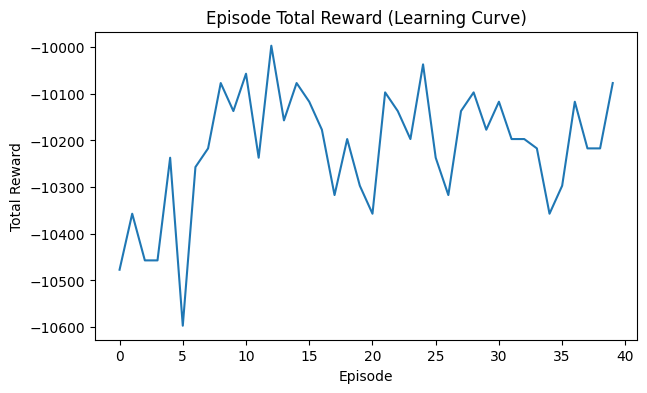

In [ ]:
EPISODES = 40
rewards_per_ep = []
policy_actions = []

for ep in range(EPISODES):
    env = SimpleIntersectionEnv(states)
    state = env.reset()
    total_reward = 0
    actions_this_ep = []
    done = False
    while not done:
        action = choose_action(state, epsilon=0.1)
        actions_this_ep.append(action)
        next_state, reward, done = env.step(action)
        update_q(state, action, reward, next_state)
        total_reward += reward
        state = next_state
    rewards_per_ep.append(total_reward)
    policy_actions.append(actions_this_ep)
    if ep % 10 == 0:
        print(f"Episode {ep} total reward: {total_reward:.2f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
plt.plot(rewards_per_ep)
plt.title("Episode Total Reward (Learning Curve)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

## 5. Evaluate Final Learned Policy

- Run 1 episode **without exploration** (always greedy action)
- Show action timeline and compare to anomaly ground truth

      frame_idx  true_vehicle_count  is_anomaly  RL_action
1978       9965                 8.0           0        1.0
1979       9966                 8.0           0        0.0
1980       9967                10.0           0        0.0
1981       9968                 6.0           0        0.0
1982       9969                12.0           0        0.0
1983       9970                 7.0           0        0.0
1984       9971                 5.0           0        0.0
1985       9972                14.0           0        0.0
1986       9973                 3.0           0        0.0
1987       9974                 5.0           0        0.0
1988       9975                 1.0           0        0.0
1989       9976                 8.0           0        0.0
1990       9977                 2.0           0        0.0
1991       9978                 6.0           0        0.0
1992       9979                12.0           0        0.0


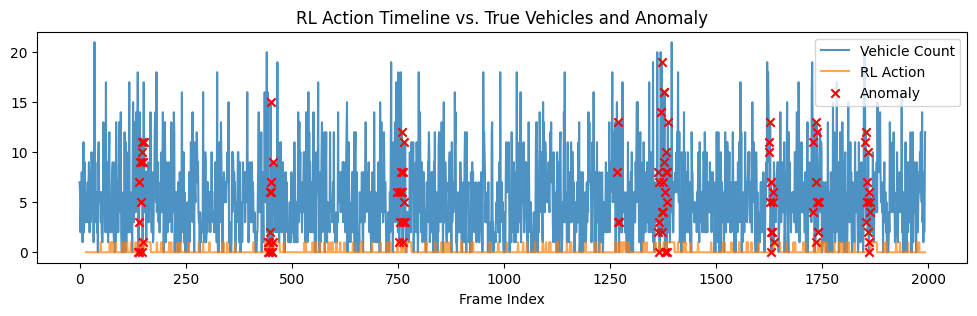

In [ ]:
# Make sure WINDOW_SIZE is defined!
WINDOW_SIZE = 15

N = len(df)
M = len(greedy_actions)

action_column = [None]*WINDOW_SIZE + list(greedy_actions)
# If it's too long, truncate:
action_column = action_column[:N]
# If it's too short (shouldn't happen, but just in case), pad at end:
while len(action_column) < N:
    action_column.append(None)

df_actions = df.copy()
df_actions['RL_action'] = action_column
df_actions['is_anomaly'] = df['is_anomaly']
print(df_actions[["frame_idx", "true_vehicle_count", "is_anomaly", "RL_action"]].tail(15))

import matplotlib.pyplot as plt
plt.figure(figsize=(12,3))
plt.plot(df_actions["true_vehicle_count"], label="Vehicle Count", alpha=0.8)
plt.plot(df_actions["RL_action"], label="RL Action", alpha=0.7)
plt.scatter(np.where(df_actions["is_anomaly"]==1),
            df_actions["true_vehicle_count"][df_actions["is_anomaly"]==1],
            color='red', marker='x', label="Anomaly", zorder=5)
plt.title("RL Action Timeline vs. True Vehicles and Anomaly")
plt.xlabel("Frame Index")
plt.legend()
plt.show()

## 6. Save Controller Actions Sequence

The chosen actions (0=Normal, 1=Anomaly/Green Extension/Intervene) for each frame.

In [ ]:
df_actions[["frame_idx", "true_vehicle_count", "vae_anomaly_score", "is_anomaly", "RL_action"]].to_csv("rl_traffic_actions.csv", index=False)
print("Saved: rl_traffic_actions.csv")

Saved: rl_traffic_actions.csv


## Discussion

- This RL agent dynamically adjusts light phases in response to both real-time congestion and detected anomalies.
- The reward design and state/action space can be extended to support emissions/fairness trade-offs, multiple intersections, or continuous control with a deep RL agent.
- Output can be used in SUMO/co-simulation, UI visualization, or directly in city-scale demo.

---

### References
- Sutton, R. S. & Barto, A. G. (2018). Reinforcement Learning: An Introduction (2nd Edition)
- Kuyer et al., "Multiagent Reinforcement Learning for Traffic Light Control", ICML 2008

---

*End of Module 5: RL-based Dynamic Traffic Control*